# Small Data Science Project: E-commerce Order Time Analysis

## Project goal
Use Python's `datetime` module and pandas datetime tools to analyze realistic e-commerce order data.

You will answer practical business questions:

1. Which hours receive the most orders?
2. Which weekdays are busiest?
3. How long does order processing take?
4. How long does delivery take?
5. What percentage of orders arrive late?
6. Do weekends have different sales patterns?
7. How do orders and revenue change by month?

The dataset is synthetic, but it is designed to resemble real e-commerce operations in Pakistan.


## Why datetime is important in Data Science

Most real world datasets contain time information:

- sales transactions
- website visits
- banking activity
- hospital records
- sensor readings
- stock prices
- deliveries
- customer support tickets

Datetime skills help a data scientist:

- clean inconsistent date columns
- sort events correctly
- calculate durations
- detect daily, weekly, monthly, and seasonal patterns
- create time based features for machine learning models
- avoid data leakage by splitting training and test data chronologically
- forecast future demand
- monitor delays and service level agreements

A date is not merely text. It contains useful features such as hour, weekday, month, quarter, weekend status, and elapsed time.


## 1. Python `datetime` module basics

In [1]:
from datetime import datetime, date, time, timedelta

# Current local date and time
now = datetime.now()
print("Current datetime:", now)
print("Current date:", now.date())
print("Current time:", now.time())

# Create a specific datetime
class_time = datetime(2026, 7, 24, 14, 30)
print("\nClass time:", class_time)

# Add and subtract time
tomorrow = now + timedelta(days=1)
two_hours_ago = now - timedelta(hours=2)
print("Tomorrow:", tomorrow)
print("Two hours ago:", two_hours_ago)


Current datetime: 2026-07-24 14:31:41.401099
Current date: 2026-07-24
Current time: 14:31:41.401099

Class time: 2026-07-24 14:30:00
Tomorrow: 2026-07-25 14:31:41.401099
Two hours ago: 2026-07-24 12:31:41.401099


### Parsing and formatting dates

- `strptime()` converts a string into a datetime.
- `strftime()` converts a datetime into a formatted string.


In [2]:
date_text = "24-07-2026 02:30 PM"

parsed_date = datetime.strptime(date_text, "%d-%m-%Y %I:%M %p")
print("Parsed datetime:", parsed_date)

formatted_date = parsed_date.strftime("%A, %d %B %Y at %I:%M %p")
print("Formatted datetime:", formatted_date)


Parsed datetime: 2026-07-24 14:30:00
Formatted datetime: Friday, 24 July 2026 at 02:30 PM


## 2. Load the real world dataset

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

DATA_FILE = "ecommerce_orders_datetime_project.csv"

df = pd.read_csv(DATA_FILE)
print("Dataset shape:", df.shape)
df.head()


Dataset shape: (500, 11)


,order_id,customer_city,province,product_category,payment_method,order_amount_pkr,order_datetime,shipped_datetime,promised_delivery_datetime,delivered_datetime,order_status
0,PK-00001,Faisalabad,Punjab,Fashion,Card,9457.17,2025-06-13 08:47:00,2025-06-13 13:47:00,2025-06-17 08:47:00,2025-06-15 16:24:00,Delivered
1,PK-00002,Karachi,Sindh,Beauty,Card,46669.07,2025-01-08 08:14:00,2025-01-09 08:14:00,2025-01-11 08:14:00,2025-01-10 21:28:00,Delivered
2,PK-00003,Islamabad,ICT,Books,Digital Wallet,22413.17,2025-03-13 19:00:00,2025-03-14 01:00:00,2025-03-16 19:00:00,2025-03-16 04:05:00,Delivered
3,PK-00004,Faisalabad,Punjab,Electronics,Digital Wallet,35063.52,2025-04-02 20:38:00,2025-04-03 10:38:00,2025-04-06 20:38:00,2025-04-08 13:13:00,Delivered
4,PK-00005,Peshawar,Khyber Pakhtunkhwa,Beauty,Card,45930.11,2025-06-10 17:55:00,2025-06-10 20:55:00,2025-06-15 17:55:00,2025-06-13 23:49:00,Delivered


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   order_id                    500 non-null    object 
 1   customer_city               500 non-null    object 
 2   province                    500 non-null    object 
 3   product_category            500 non-null    object 
 4   payment_method              500 non-null    object 
 5   order_amount_pkr            500 non-null    float64
 6   order_datetime              500 non-null    object 
 7   shipped_datetime            466 non-null    object 
 8   promised_delivery_datetime  500 non-null    object 
 9   delivered_datetime          466 non-null    object 
 10  order_status                500 non-null    object 
dtypes: float64(1), object(10)
memory usage: 43.1+ KB


## 3. Convert text columns to datetime

CSV files usually store dates as text. Before analysis, convert them into a datetime data type.

`errors="coerce"` changes invalid or missing values into `NaT`the datetime equivalent of a missing value.


In [5]:
datetime_columns = [
    "order_datetime",
    "shipped_datetime",
    "promised_delivery_datetime",
    "delivered_datetime",
]

for column in datetime_columns:
    df[column] = pd.to_datetime(df[column], errors="coerce")

df[datetime_columns].dtypes


order_datetime                datetime64[ns]
shipped_datetime              datetime64[ns]
promised_delivery_datetime    datetime64[ns]
delivered_datetime            datetime64[ns]
dtype: object

In [6]:
# Check missing datetime values
df[datetime_columns].isna().sum()


order_datetime                 0
shipped_datetime              34
promised_delivery_datetime     0
delivered_datetime            34
dtype: int64

## 4. Create datetime features

These features can be used for exploratory analysis and machine learning models.


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   order_id                    500 non-null    object        
 1   customer_city               500 non-null    object        
 2   province                    500 non-null    object        
 3   product_category            500 non-null    object        
 4   payment_method              500 non-null    object        
 5   order_amount_pkr            500 non-null    float64       
 6   order_datetime              500 non-null    datetime64[ns]
 7   shipped_datetime            466 non-null    datetime64[ns]
 8   promised_delivery_datetime  500 non-null    datetime64[ns]
 9   delivered_datetime          466 non-null    datetime64[ns]
 10  order_status                500 non-null    object        
dtypes: datetime64[ns](4), float64(1), object(6)
memory usage: 

In [8]:
df["order_date"] = df["order_datetime"].dt.date
df["order_year"] = df["order_datetime"].dt.year
df["order_month"] = df["order_datetime"].dt.month
df["month_name"] = df["order_datetime"].dt.month_name()
df["order_day"] = df["order_datetime"].dt.day
df["weekday_name"] = df["order_datetime"].dt.day_name()
df["weekday_number"] = df["order_datetime"].dt.dayofweek
df["order_hour"] = df["order_datetime"].dt.hour
df["is_weekend"] = df["weekday_number"].isin([5, 6])
df["year_month"] = df["order_datetime"].dt.to_period("M").astype(str)

df[[
    "order_datetime", "order_date", "month_name",
    "weekday_name", "order_hour", "is_weekend"
]].head()


,order_datetime,order_date,month_name,weekday_name,order_hour,is_weekend
0,2025-06-13 08:47:00,2025-06-13,June,Friday,8,False
1,2025-01-08 08:14:00,2025-01-08,January,Wednesday,8,False
2,2025-03-13 19:00:00,2025-03-13,March,Thursday,19,False
3,2025-04-02 20:38:00,2025-04-02,April,Wednesday,20,False
4,2025-06-10 17:55:00,2025-06-10,June,Tuesday,17,False


## 5. Calculate processing and delivery durations

In [10]:
df["processing_hours"] = (
    df["shipped_datetime"] - df["order_datetime"]
).dt.total_seconds() / 3600

df["delivery_hours"] = (
    df["delivered_datetime"] - df["shipped_datetime"]
).dt.total_seconds() / 3600

df["total_fulfilment_days"] = (
    df["delivered_datetime"] - df["order_datetime"]
).dt.total_seconds() / 86400

df["is_late"] = (
    df["delivered_datetime"] > df["promised_delivery_datetime"]
)

df[[
    "order_id", "processing_hours", "delivery_hours",
    "total_fulfilment_days", "is_late"
]]


,order_id,processing_hours,delivery_hours,total_fulfilment_days,is_late
0,PK-00001,5.0,50.616667,2.317361,False
1,PK-00002,24.0,37.233333,2.551389,False
2,PK-00003,6.0,51.083333,2.378472,False
3,PK-00004,14.0,122.583333,5.690972,True
4,PK-00005,3.0,74.900000,3.245833,False
...,...,...,...,...,...
495,PK-00496,7.0,130.600000,5.733333,False
496,PK-00497,11.0,57.666667,2.861111,False
497,PK-00498,17.0,24.633333,1.734722,False
498,PK-00499,21.0,56.650000,3.235417,False


## 6. Business analysis

In [11]:
delivered = df[df["order_status"] == "Delivered"].copy()

summary = {
    "total_orders": len(df),
    "delivered_orders": len(delivered),
    "cancelled_orders": (df["order_status"] == "Cancelled").sum(),
    "total_revenue_pkr": round(delivered["order_amount_pkr"].sum(), 2),
    "average_order_value_pkr": round(delivered["order_amount_pkr"].mean(), 2),
    "average_processing_hours": round(delivered["processing_hours"].mean(), 2),
    "average_fulfilment_days": round(delivered["total_fulfilment_days"].mean(), 2),
    "late_delivery_rate_percent": round(delivered["is_late"].mean() * 100, 2),
}

pd.Series(summary, name="value")


total_orders                       500.00
delivered_orders                   466.00
cancelled_orders                    34.00
total_revenue_pkr             15182016.20
average_order_value_pkr          32579.43
average_processing_hours            15.78
average_fulfilment_days              4.01
late_delivery_rate_percent          50.86
Name: value, dtype: float64

### Orders by hour

This helps with staff scheduling, server capacity planning, and marketing campaign timing.


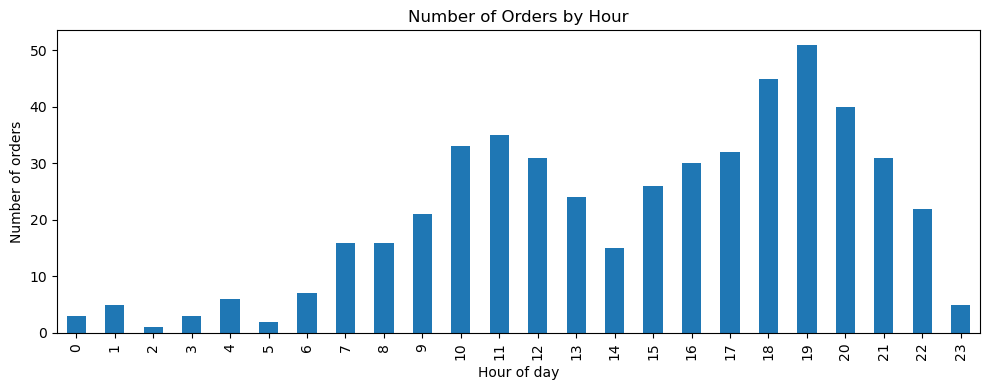

Peak order hour: 19


In [12]:
orders_by_hour = df.groupby("order_hour").size()

ax = orders_by_hour.plot(
    kind="bar",
    figsize=(10, 4),
    title="Number of Orders by Hour"
)
ax.set_xlabel("Hour of day")
ax.set_ylabel("Number of orders")
plt.tight_layout()
plt.show()

print("Peak order hour:", orders_by_hour.idxmax())


### Orders by weekday

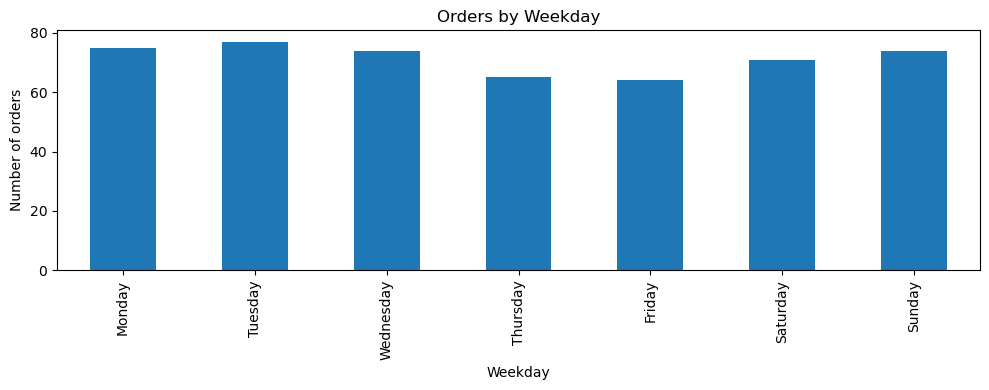

In [13]:
weekday_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
]

orders_by_weekday = (
    df.groupby("weekday_name")
      .size()
      .reindex(weekday_order)
)

ax = orders_by_weekday.plot(
    kind="bar",
    figsize=(10, 4),
    title="Orders by Weekday"
)
ax.set_xlabel("Weekday")
ax.set_ylabel("Number of orders")
plt.tight_layout()
plt.show()


### Monthly orders and revenue

Datetime grouping is essential for trend analysis, reporting, and forecasting.


In [14]:
monthly_summary = (
    delivered.groupby("year_month")
    .agg(
        orders=("order_id", "count"),
        revenue_pkr=("order_amount_pkr", "sum"),
        average_order_value_pkr=("order_amount_pkr", "mean"),
        average_fulfilment_days=("total_fulfilment_days", "mean"),
    )
    .round(2)
)

monthly_summary


,orders,revenue_pkr,average_order_value_pkr,average_fulfilment_days
year_month,,,,
2025-01,72,2595858.85,36053.60,4.22
2025-02,52,1567444.50,30143.16,4.11
2025-03,86,2807352.64,32643.64,3.93
2025-04,86,2736070.49,31814.77,3.93
2025-05,84,2687225.61,31990.78,3.92
2025-06,86,2788064.11,32419.35,4.04


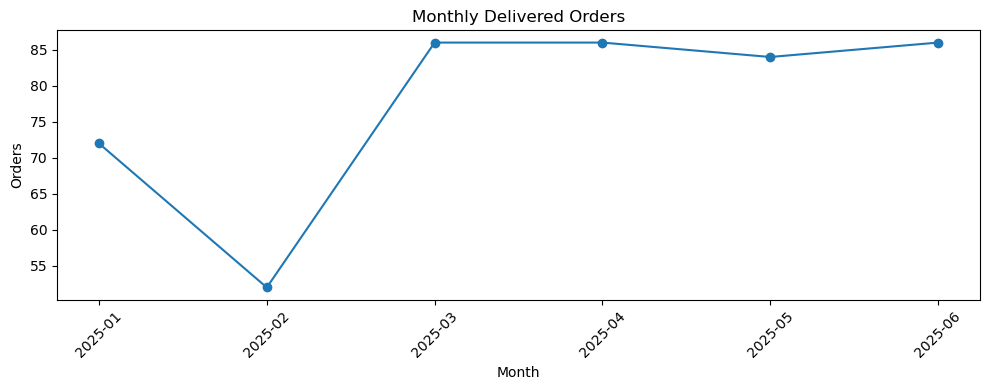

In [15]:
ax = monthly_summary["orders"].plot(
    marker="o",
    figsize=(10, 4),
    title="Monthly Delivered Orders"
)
ax.set_xlabel("Month")
ax.set_ylabel("Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Late delivery rate by city

This can identify logistics problems and locations needing operational improvement.


In [16]:
city_delivery = (
    delivered.groupby("customer_city")
    .agg(
        delivered_orders=("order_id", "count"),
        average_fulfilment_days=("total_fulfilment_days", "mean"),
        late_delivery_rate=("is_late", "mean"),
    )
)

city_delivery["late_delivery_rate_percent"] = (
    city_delivery["late_delivery_rate"] * 100
)

city_delivery.drop(columns="late_delivery_rate").round(2).sort_values(
    "late_delivery_rate_percent",
    ascending=False
)


,delivered_orders,average_fulfilment_days,late_delivery_rate_percent
customer_city,,,
Quetta,62,6.53,61.29
Lahore,56,3.09,55.36
Karachi,58,3.28,55.17
Multan,60,4.07,55.00
Faisalabad,62,4.00,53.23
Islamabad,66,3.10,46.97
Peshawar,55,4.88,43.64
Rawalpindi,47,2.92,31.91


### Weekend versus weekday behavior

In [17]:
weekend_comparison = (
    delivered.groupby("is_weekend")
    .agg(
        orders=("order_id", "count"),
        total_revenue_pkr=("order_amount_pkr", "sum"),
        average_order_value_pkr=("order_amount_pkr", "mean"),
    )
    .rename(index={False: "Weekday", True: "Weekend"})
    .round(2)
)

weekend_comparison


,orders,total_revenue_pkr,average_order_value_pkr
is_weekend,,,
Weekday,328,10695033.43,32606.81
Weekend,138,4486982.77,32514.37


## 7. Data quality checks

Datetime data often contains impossible sequences. For example, a shipment should not occur before its order.


In [18]:
invalid_shipping_sequence = df[
    df["shipped_datetime"] < df["order_datetime"]
]

invalid_delivery_sequence = df[
    df["delivered_datetime"] < df["shipped_datetime"]
]

print("Shipments before orders:", len(invalid_shipping_sequence))
print("Deliveries before shipments:", len(invalid_delivery_sequence))


Shipments before orders: 0
Deliveries before shipments: 0


## 8. Simple machine learning feature table

A future model could predict whether an order will be late. Datetime derived columns become model inputs.


In [20]:
model_features = delivered[[
    "order_hour",
    "weekday_number",
    "order_month",
    "is_weekend",
    "order_amount_pkr",
    "processing_hours",
    "customer_city",
    "product_category",
    "payment_method",
    "is_late",
]].copy()

model_features


,order_hour,weekday_number,order_month,is_weekend,order_amount_pkr,processing_hours,customer_city,product_category,payment_method,is_late
0,8,4,6,False,9457.17,5.0,Faisalabad,Fashion,Card,False
1,8,2,1,False,46669.07,24.0,Karachi,Beauty,Card,False
2,19,3,3,False,22413.17,6.0,Islamabad,Books,Digital Wallet,False
3,20,2,4,False,35063.52,14.0,Faisalabad,Electronics,Digital Wallet,True
4,17,1,6,False,45930.11,3.0,Peshawar,Beauty,Card,False
...,...,...,...,...,...,...,...,...,...,...
495,17,6,5,True,3284.14,7.0,Quetta,Beauty,Digital Wallet,False
496,9,5,2,True,27534.00,11.0,Islamabad,Books,Cash on Delivery,False
497,22,0,2,False,32571.86,17.0,Faisalabad,Electronics,Digital Wallet,False
498,10,6,3,True,28973.05,21.0,Multan,Home,Digital Wallet,False


## Key lessons

1. Convert date strings into proper datetime values.
2. Extract hour, weekday, month, and weekend features.
3. Use datetime subtraction to calculate durations.
4. Group records by time periods to discover trends.
5. Validate chronological order to catch data errors.
6. Use datetime derived features in machine learning models.
7. Use chronological splits for time dependent prediction problems.

## Practice tasks

1. Find the top three busiest dates.
2. Calculate cancellation rate by weekday.
3. Find the category with the fastest average delivery.
4. Compare morning, afternoon, evening, and night orders.
5. Calculate weekly revenue using `resample("W")`.
6. Create a feature called `days_since_first_order`.
7. Build a basic classifier to predict `is_late`.
